### Feature Engineering

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path

In [2]:
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)

PROCESSED = Path("../data/processed")

In [4]:
# ── Load global feature stats (from Global Kaggle preprocessing) ─────────────
# Global Kaggle had NO coordinates → its patterns are stored as JSON weights
import json

global_stats_path = PROCESSED / "global_feature_stats.json"
if global_stats_path.exists():
    with open(global_stats_path) as f:
        global_stats = json.load(f)

    # Build quick lookup dicts from the stats
    WEATHER_SEV_LOOKUP = {
        r["Weather Conditions"]: r["avg_severity"]
        for r in global_stats["weather_risk"]
    }
    ROAD_SEV_LOOKUP = {
        r["Road Type"]: r["avg_severity"]
        for r in global_stats["road_type_risk"]
    }
    CAUSE_SEV_LOOKUP = {
        r["Accident Cause"]: r["avg_severity"]
        for r in global_stats["cause_risk"]
    }
    print(" Global feature stats loaded from global_feature_stats.json")
    print(f"   Weather risk entries  : {len(WEATHER_SEV_LOOKUP)}")
    print(f"   Road type risk entries: {len(ROAD_SEV_LOOKUP)}")
    print(f"   Cause risk entries    : {len(CAUSE_SEV_LOOKUP)}")
    print()
    print("Weather severity lookup (from 132K global records):")
    for k, v in sorted(WEATHER_SEV_LOOKUP.items(), key=lambda x: -x[1]):
        print(f"   {k:<20} avg_severity = {v:.3f}")
else:
    print("⚠️  global_feature_stats.json not found.")
    print("    Run 02_preprocessing.ipynb first.")
    WEATHER_SEV_LOOKUP = {}
    ROAD_SEV_LOOKUP    = {}
    CAUSE_SEV_LOOKUP   = {}

 Global feature stats loaded from global_feature_stats.json
   Weather risk entries  : 5
   Road type risk entries: 3
   Cause risk entries    : 5

Weather severity lookup (from 132K global records):
   Snowy                avg_severity = 2.004
   Foggy                avg_severity = 2.003
   Clear                avg_severity = 1.997
   Rainy                avg_severity = 1.996
   Windy                avg_severity = 1.995


In [19]:
# Load cleaned data
df = pd.read_parquet(PROCESSED / "cleaned_spatial.parquet")
print(f"Loaded cleaned_spatial.parquet: {df.shape[0]:,} rows × {df.shape[1]} cols")
print(df.dtypes.value_counts())
df.head(3)

Loaded cleaned_spatial.parquet: 5,898 rows × 20 cols
str        12
int64       5
float64     3
Name: count, dtype: int64


,latitude,longitude,severity,killed,injured,weather,road_type,road_condition,lighting,speed_limit,state,country,year,month,hour,cause,vehicle_type,crash_type,area_type,source
0,18.278457,76.009574,4,4,0,unknown,nh,unknown,unknown,NaN,Maharashtra,India,2022,January,-1,head on collision,car,head on collision,unknown,mendeley_india_2022_2023
1,24.543681,84.280571,4,6,18,unknown,nh,unknown,unknown,NaN,Jharkhand,India,2022,January,-1,head on collision,pick up,head on collision,unknown,mendeley_india_2022_2023
2,15.390068,73.854974,4,3,2,unknown,nh,unknown,unknown,NaN,Goa,India,2022,January,-1,fixed object collision,car,fixed object collision,unknown,mendeley_india_2022_2023


### 1. H3 Spatial Features

In [20]:
# H3 — Uber's hexagonal grid — divides earth into equal hex cells
# Resolution 9 ≈ 174m diameter — ideal for blackspot detection
import h3
H3_AVAILABLE = True

In [21]:
if H3_AVAILABLE:
    print("Assigning H3 cells (resolution 9)...")
    #------------------------------old not used now#
    # df["h3_r9"] = df.apply(
    #     lambda r: h3.geo_to_h3(r["latitude"], r["longitude"], 9), axis=1)
    # df["h3_r8"] = df.apply(
    #     lambda r: h3.geo_to_h3(r["latitude"], r["longitude"], 8), axis=1)
    #-------------------------------old not used now#
    df["h3_r9"] = df.apply(
    lambda r: h3.latlng_to_cell(r["latitude"], r["longitude"], 9), axis=1
    )
    df["h3_r8"] = df.apply(
        lambda r: h3.latlng_to_cell(r["latitude"], r["longitude"], 8), axis=1
    )
    # r8 ≈ 461m — coarser view for cluster detection
    print(f"  Unique H3-r9 cells: {df['h3_r9'].nunique():,}")
    print(f"  Unique H3-r8 cells: {df['h3_r8'].nunique():,}")
else:
    # Fallback: round coordinates to grid (~1km cells)
    df["h3_r9"] = (df["latitude"].round(2).astype(str) + "_" +
                   df["longitude"].round(2).astype(str))
    df["h3_r8"] = (df["latitude"].round(1).astype(str) + "_" +
                   df["longitude"].round(1).astype(str))
    print(f"  Grid cells r9 (~1km): {df['h3_r9'].nunique():,}")
    print(f"  Grid cells r8 (~10km): {df['h3_r8'].nunique():,}")

Assigning H3 cells (resolution 9)...
  Unique H3-r9 cells: 5,788
  Unique H3-r8 cells: 5,678


In [22]:
# ── Accident density per hex cell ─────────────────────────────
hex_density_r9 = df.groupby("h3_r9").size().rename("hex_density_r9")
hex_density_r8 = df.groupby("h3_r8").size().rename("hex_density_r8")

df = df.merge(hex_density_r9, on="h3_r9", how="left")
df = df.merge(hex_density_r8, on="h3_r8", how="left")

print("Hex density distribution (r9):")
print(df["hex_density_r9"].describe().round(2).to_string())
print()
print("Top 10 densest hex cells:")
print(hex_density_r9.nlargest(10).to_string())

Hex density distribution (r9):
count    5898.00
mean        1.04
std         0.21
min         1.00
25%         1.00
50%         1.00
75%         1.00
max         3.00

Top 10 densest hex cells:
h3_r9
896088cde6bffff    3
89608bcecabffff    3
896099a2b63ffff    3
896099a2b7bffff    3
896099a3103ffff    3
896099a354bffff    3
89618eb1957ffff    3
893c8e41d27ffff    2
893c9034237ffff    2
893c9254c57ffff    2


In [23]:
# ── Hex severity score (avg severity per hex cell) ────────────
hex_sev = df.groupby("h3_r9")["severity"].mean().rename("hex_avg_severity")
df = df.merge(hex_sev, on="h3_r9", how="left")

# ── Hex fatality rate ─────────────────────────────────────────
hex_fat = df.groupby("h3_r9")["killed"].sum().rename("hex_total_killed")
df = df.merge(hex_fat, on="h3_r9", how="left")

print(" Spatial hex features created:")
# print(f"   hex_density_r9   : {df['hex_density_r9'].describe()['mean']:.2f} avg accidents/cell")
# print(f"   hex_avg_severity : {df['hex_avg_severity'].describe()['mean']:.2f} avg severity/cell")
# print(f"   hex_total_killed : {df['hex_total_killed'].describe()['sum']:.0f} total fatalities")
print(" Spatial hex features created:")
print(f"   hex_density_r9   : {df['hex_density_r9'].mean():.2f} avg accidents/cell")
print(f"   hex_avg_severity : {df['hex_avg_severity'].mean():.2f} avg severity/cell")
print(f"   hex_total_killed : {hex_fat.sum():.0f} total fatalities")

 Spatial hex features created:
 Spatial hex features created:
   hex_density_r9   : 1.04 avg accidents/cell
   hex_avg_severity : 2.63 avg severity/cell
   hex_total_killed : 13950 total fatalities


### Time based feature

In [24]:
# Hour bucket
def hour_to_bucket(h):
    if h < 0:    return "unknown"
    if h < 6:    return "night"
    if h < 12:   return "morning"
    if h < 18:   return "afternoon"
    return "evening"

df["hour_bucket"] = df["hour"].apply(hour_to_bucket)

# is_night: 20:00 – 05:59
df["is_night"] = ((df["hour"] >= 20) | (df["hour"] <= 5)).astype(int)
df.loc[df["hour"] < 0, "is_night"] = 0  # unknown hour

# is_weekend
WEEKEND = ["saturday","sunday"]
df["is_weekend"] = 0  # default
# if day_of_week column available from kaggle india
if "Day of Week" in df.columns:
    df["is_weekend"] = df["Day of Week"].str.lower().isin(WEEKEND).astype(int)

# is_monsoon: July, August, September, October
MONSOON = ["july","august","september","october","jul","aug","sep","oct"]
df["is_monsoon"] = df["month"].str.lower().isin(MONSOON).astype(int)

# is_peak_hour: 08–10 and 17–20
df["is_peak_hour"] = df["hour"].apply(
    lambda h: 1 if (8 <= h <= 10 or 17 <= h <= 20) else 0)

print("Time features created:")
print(f"  is_night    : {df['is_night'].sum():,} rows ({df['is_night'].mean()*100:.1f}%)")
print(f"  is_monsoon  : {df['is_monsoon'].sum():,} rows ({df['is_monsoon'].mean()*100:.1f}%)")
print(f"  is_peak_hour: {df['is_peak_hour'].sum():,} rows ({df['is_peak_hour'].mean()*100:.1f}%)")
print()
print("Hour bucket distribution:")
print(df["hour_bucket"].value_counts().to_string())

Time features created:
  is_night    : 1,290 rows (21.9%)
  is_monsoon  : 1,920 rows (32.6%)
  is_peak_hour: 849 rows (14.4%)

Hour bucket distribution:
hour_bucket
unknown      2898
night         784
morning       761
afternoon     728
evening       727


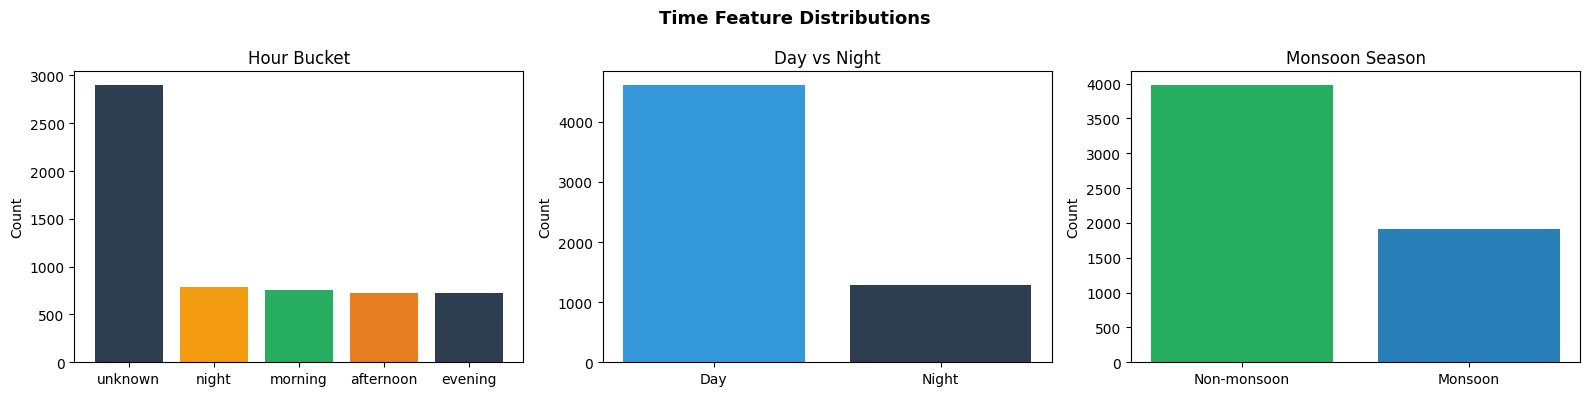

In [25]:
# Visualise time features
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Time Feature Distributions", fontsize=13, fontweight="bold")

hb = df["hour_bucket"].value_counts()
axes[0].bar(hb.index, hb.values, color=["#2c3e50","#f39c12","#27ae60","#e67e22"])
axes[0].set_title("Hour Bucket")
axes[0].set_ylabel("Count")

axes[1].bar(["Day","Night"], [
    (df["is_night"]==0).sum(), (df["is_night"]==1).sum()
], color=["#3498db","#2c3e50"])
axes[1].set_title("Day vs Night")
axes[1].set_ylabel("Count")

axes[2].bar(["Non-monsoon","Monsoon"], [
    (df["is_monsoon"]==0).sum(), (df["is_monsoon"]==1).sum()
], color=["#27ae60","#2980b9"])
axes[2].set_title("Monsoon Season")
axes[2].set_ylabel("Count")

plt.tight_layout()
plt.savefig(PROCESSED / "fe_time_features.png", dpi=120)
plt.show()

### Risk Factor Features

In [26]:
# ── Speed Risk ───────────────────────────────────────────────
# Based on MoRTH: over-speeding = 68% of India accidents
def speed_risk(speed):
    if pd.isna(speed) or speed <= 0: return 2  # default medium
    if speed >= 100: return 4    # extreme
    if speed >= 80:  return 3    # high
    if speed >= 60:  return 2    # medium
    return 1                     # low

In [27]:
df["speed_risk"] = df["speed_limit"].apply(speed_risk)

In [28]:
# ── Weather Risk (calibrated from Global Kaggle 132K records) ─────────────────
# Use global_feature_stats.json lookup first, fall back to manual mapping

# ────
WEATHER_RISK = {
    "clear": 1, "sunny": 1, "fine": 1,
    "cloudy": 1, "overcast": 1, "hazy": 2,
    "rainy": 3, "rain": 3, "drizzle": 2,
    "foggy": 4, "fog": 4, "mist": 3,
    "stormy": 4, "storm": 4, "windy": 2,
    "snowy": 4, "snow": 4, "icy": 4,
    "unknown": 2,
}

In [29]:
def weather_risk(w):
    w = str(w).lower().strip()
    for key, score in WEATHER_RISK.items():
        if key in w:
            return score
    return 2

df["weather_risk"] = df["weather"].apply(weather_risk)

In [30]:
# ── Road Condition Risk ───────────────────────────────────────
ROAD_COND_RISK = {
    "dry": 1, "good": 1,
    "wet": 2, "damp": 2,
    "damaged": 3, "pothole": 3,
    "under construction": 4, "construction": 4,
    "icy": 4, "snow": 4,
    "unknown": 2,
}

In [31]:
def road_cond_risk(r):
    r = str(r).lower().strip()
    for key, score in ROAD_COND_RISK.items():
        if key in r:
            return score
    return 2

df["road_cond_risk"] = df["road_condition"].apply(road_cond_risk)

In [32]:
# ── Lighting Risk ─────────────────────────────────────────────
LIGHTING_RISK = {
    "daylight": 1, "day": 1,
    "dusk": 2, "dawn": 2, "dim": 2,
    "dark": 3, "night": 3,
    "unknown": 2,
}

def lighting_risk(l):
    l = str(l).lower().strip()
    for key, score in LIGHTING_RISK.items():
        if key in l:
            return score
    return 2

df["lighting_risk"] = df["lighting"].apply(lighting_risk)

In [33]:
# ── Road Type Risk ────────────────────────────────────────────
ROAD_TYPE_RISK = {
    "national highway": 4, "nh": 4, "highway": 3,
    "state highway": 3, "sh": 3,
    "urban road": 2, "city": 2,
    "village road": 2, "rural": 2,
    "main road": 2, "street": 1,
    "unknown": 2,
}

def road_type_risk(r):
    r = str(r).lower().strip()
    for key, score in ROAD_TYPE_RISK.items():
        if key in r:
            return score
    return 2

In [34]:
df["road_type_risk"] = df["road_type"].apply(road_type_risk)

print("Risk features created:")
for col in ["speed_risk","weather_risk","road_cond_risk","lighting_risk","road_type_risk"]:
    print(f"  {col:<20} mean={df[col].mean():.2f} | dist={df[col].value_counts().to_dict()}")

Risk features created:
  speed_risk           mean=2.19 | dist={2: 3535, 1: 1004, 4: 738, 3: 621}
  weather_risk         mean=2.41 | dist={2: 3506, 4: 1187, 3: 631, 1: 574}
  road_cond_risk       mean=2.26 | dist={2: 3648, 4: 778, 1: 761, 3: 711}
  lighting_risk        mean=2.00 | dist={2: 4382, 3: 763, 1: 753}
  road_type_risk       mean=2.79 | dist={2: 2937, 4: 1710, 3: 1251}


Environmental risk score distribution:
count    5898.000
mean        2.308
std         0.416
min         1.150
25%         2.000
50%         2.250
75%         2.500
max         3.850


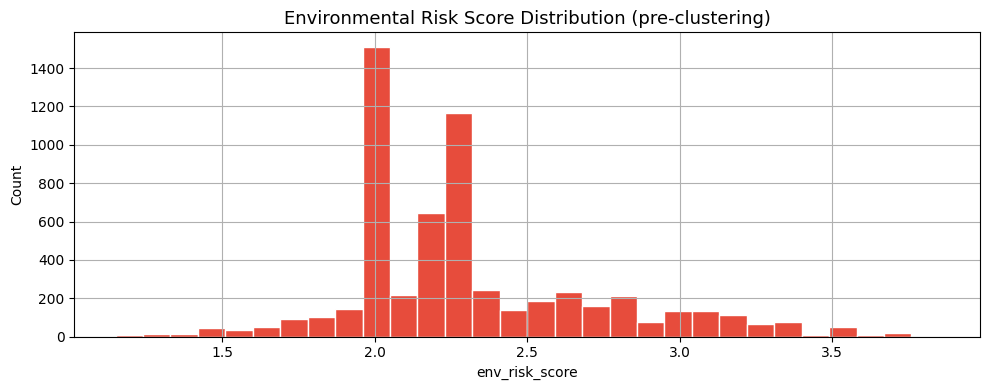

In [35]:
# Composite environmental risk score (before DBSCAN)
df["env_risk_score"] = (
    df["speed_risk"]     * 0.30 +
    df["weather_risk"]   * 0.20 +
    df["road_cond_risk"] * 0.20 +
    df["lighting_risk"]  * 0.15 +
    df["road_type_risk"] * 0.15
)

print("Environmental risk score distribution:")
print(df["env_risk_score"].describe().round(3).to_string())

plt.figure(figsize=(10, 4))
df["env_risk_score"].hist(bins=30, color="#e74c3c", edgecolor="white")
plt.title("Environmental Risk Score Distribution (pre-clustering)", fontsize=13)
plt.xlabel("env_risk_score")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(PROCESSED / "fe_env_risk_dist.png", dpi=120)
plt.show()

In [36]:
# Join state-level risk weights computed in preprocessing
state_weights = pd.read_csv(PROCESSED / "state_risk_weights.csv")
print("State risk weights:")
print(state_weights[["state","accidents_2023","state_risk_weight"]]
      .sort_values("state_risk_weight", ascending=False).to_string(index=False))

State risk weights:
                    state  accidents_2023  state_risk_weight
               Tamil Nadu         67213.0              2.000
           Madhya Pradesh         55327.0              1.972
                   Kerala         48091.0              1.944
            Uttar Pradesh         44534.0              1.917
                Karnataka         43440.0              1.889
              Maharashtra         35243.0              1.861
                Rajasthan         24694.0              1.833
                Telangana         22903.0              1.806
           Andhra Pradesh         19949.0              1.778
                  Gujarat         16349.0              1.750
              West Bengal         13795.0              1.722
             Chhattisgarh         13468.0              1.694
                   Odisha         11992.0              1.667
                    Bihar         11014.0              1.639
                  Haryana         10463.0              1.611
    

In [37]:
# Normalise state names for join
df["state_norm"]            = df["state"].str.strip().str.title()
state_weights["state_norm"] = state_weights["state"].str.strip().str.title()

df = df.merge(state_weights[["state_norm","state_risk_weight"]],
              on="state_norm", how="left")
df["state_risk_weight"] = df["state_risk_weight"].fillna(1.0)

print(f"State weight joined for {df['state_risk_weight'].notna().sum():,} rows")
print(f"Unmatched (weight=1.0): {(df['state_risk_weight']==1.0).sum():,} rows")

State weight joined for 5,898 rows
Unmatched (weight=1.0): 147 rows


### Encode Categorical Features

In [39]:
from sklearn.preprocessing import LabelEncoder

CAT_COLS = ["weather","road_type","road_condition","lighting",
            "cause","vehicle_type","crash_type","hour_bucket","country"]

encoders = {}
for col in CAT_COLS:
    if col in df.columns:
        le = LabelEncoder()
        df[f"{col}_enc"] = le.fit_transform(df[col].fillna("unknown").astype(str))
        encoders[col] = le

print(f" Encoded {len(encoders)} categorical columns")
print("New encoded columns:")
for col in CAT_COLS:
    if col in df.columns:
        print(f"  {col}_enc  → {df[f'{col}_enc'].nunique()} unique values")

 Encoded 9 categorical columns
New encoded columns:
  weather_enc  → 6 unique values
  road_type_enc  → 7 unique values
  road_condition_enc  → 5 unique values
  lighting_enc  → 5 unique values
  cause_enc  → 10 unique values
  vehicle_type_enc  → 20 unique values
  crash_type_enc  → 13 unique values
  hour_bucket_enc  → 5 unique values
  country_enc  → 1 unique values


### Feature Correlation Analysis

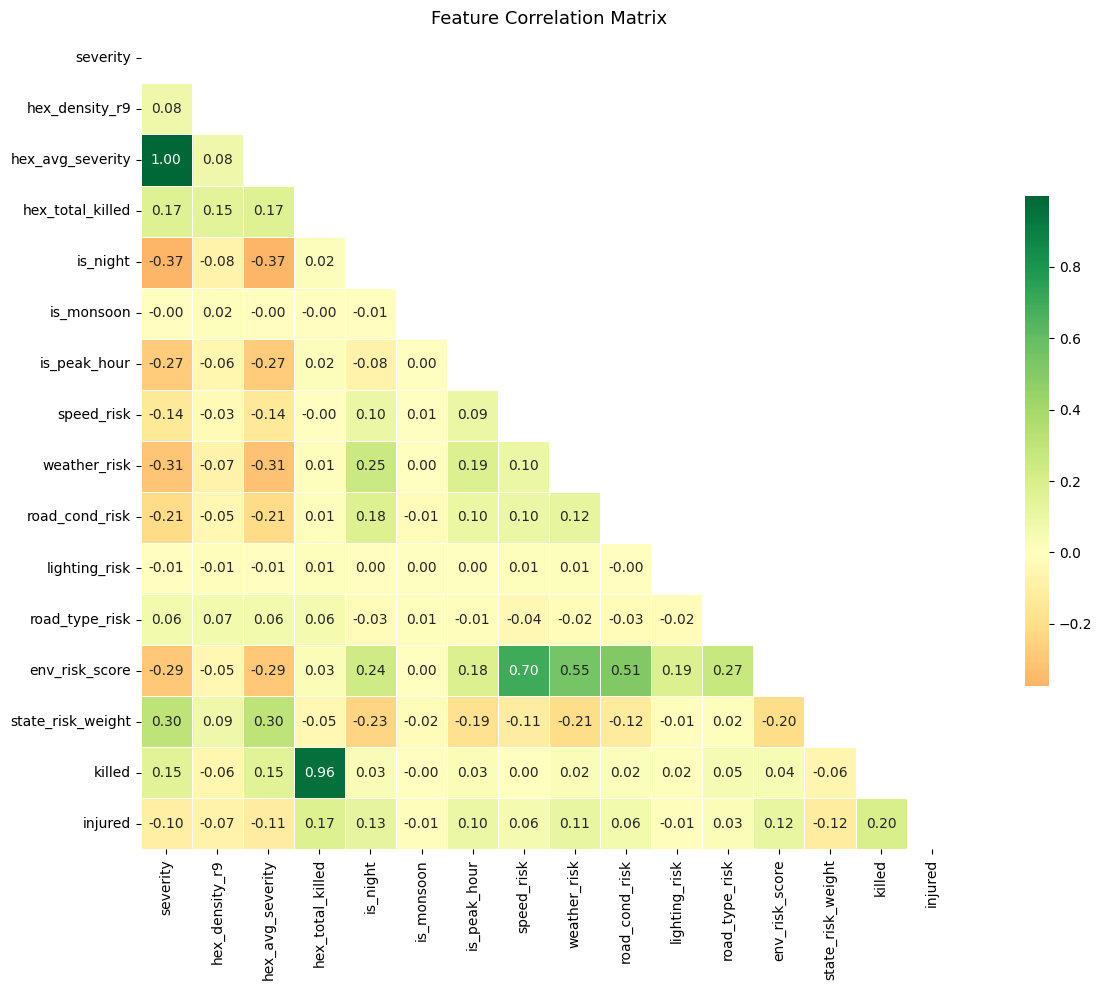

In [40]:
# Correlation of all numeric features with severity
numeric_features = [
    "severity","hex_density_r9","hex_avg_severity","hex_total_killed",
    "is_night","is_monsoon","is_peak_hour",
    "speed_risk","weather_risk","road_cond_risk","lighting_risk",
    "road_type_risk","env_risk_score","state_risk_weight","killed","injured"
]
existing = [f for f in numeric_features if f in df.columns]
corr = df[existing].corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
            cmap="RdYlGn", center=0,
            linewidths=0.5, square=True, cbar_kws={"shrink":.6})
plt.title("Feature Correlation Matrix", fontsize=13)
plt.tight_layout()
plt.savefig(PROCESSED / "fe_correlation_matrix.png", dpi=120)
plt.show()


Features most correlated with Severity:
hex_avg_severity     0.998
is_night            -0.373
weather_risk        -0.308
state_risk_weight    0.304
env_risk_score      -0.291
is_peak_hour        -0.275
road_cond_risk      -0.213
hex_total_killed     0.166
killed               0.152
speed_risk          -0.140
injured             -0.105
hex_density_r9       0.085
road_type_risk       0.063
lighting_risk       -0.008
is_monsoon          -0.002


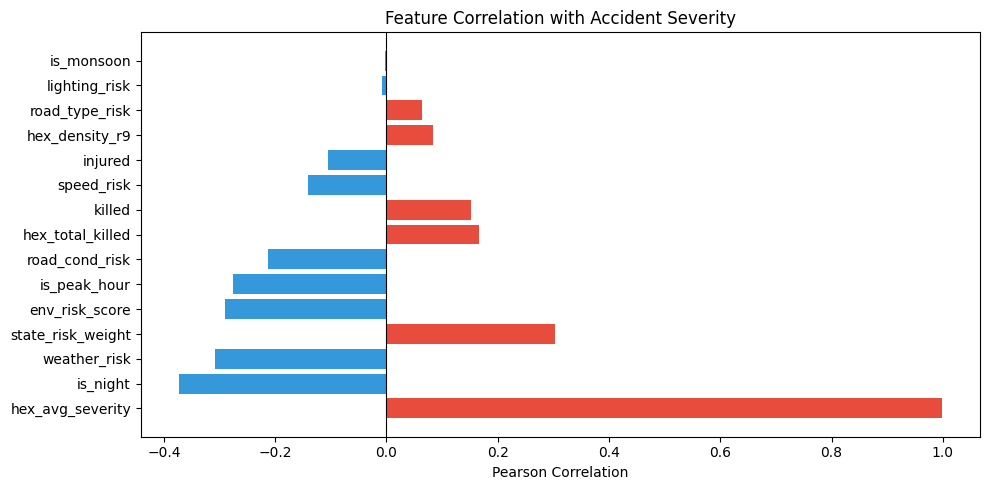

In [41]:
# Feature importance preview — correlation with severity
sev_corr = corr["severity"].drop("severity").sort_values(key=abs, ascending=False)
print("\nFeatures most correlated with Severity:")
print(sev_corr.round(3).to_string())

plt.figure(figsize=(10, 5))
colors = ["#e74c3c" if v > 0 else "#3498db" for v in sev_corr.values]
plt.barh(sev_corr.index, sev_corr.values, color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Feature Correlation with Accident Severity", fontsize=12)
plt.xlabel("Pearson Correlation")
plt.tight_layout()
plt.savefig(PROCESSED / "fe_severity_correlations.png", dpi=120)
plt.show()

### Saving feature data

In [43]:
# Summary of all features built
feature_cols = [c for c in df.columns]
print(f"Total columns in featured dataset: {len(feature_cols)}")
print("\nAll columns:")
for c in feature_cols:
    print(f"  {c:<35} {str(df[c].dtype):<12} nulls={df[c].isna().sum()}")

Total columns in featured dataset: 48

All columns:
  latitude                            float64      nulls=0
  longitude                           float64      nulls=0
  severity                            int64        nulls=0
  killed                              int64        nulls=0
  injured                             int64        nulls=0
  weather                             str          nulls=0
  road_type                           str          nulls=0
  road_condition                      str          nulls=0
  lighting                            str          nulls=0
  speed_limit                         float64      nulls=2898
  state                               str          nulls=0
  country                             str          nulls=0
  year                                int64        nulls=0
  month                               str          nulls=0
  hour                                int64        nulls=0
  cause                               str          nulls=0
 

In [45]:
out_path = PROCESSED / "featured_spatial.parquet"
df.to_parquet(out_path, index=False)
print(f" Saved featured.parquet")
print(f"   Path  : {out_path}")
print(f"   Shape : {df.shape}")
print(f"   Size  : {out_path.stat().st_size / 1024:.1f} KB")

# Save encoders for later use in API
import joblib
joblib.dump(encoders, PROCESSED / "label_encoders.pkl")
print(" Saved label_encoders.pkl")
print("\nNext → 04_modeling.ipynb")

 Saved featured.parquet
   Path  : ..\data\processed\featured_spatial.parquet
   Shape : (5898, 48)
   Size  : 321.2 KB
 Saved label_encoders.pkl

Next → 04_modeling.ipynb
